# Euler Beam under Point Load

Demonstrate that the deflection is  theta_A=P*a*b*(L+b)/(6*E*I*L)

In [1]:
import sympy as sp
from jupyter_client.client import validate_string_dict
from sympy import init_printing, simplify, pprint
sp.init_printing(order='lex')

# Define symbols for reactions and moments
R_A, M_A, R_B, M_B = sp.symbols('R_A M_A R_B M_B', real=True)

# needed for the continuity equations
x, L, a, b, P, E, I = sp.symbols('x L a b P E I', positive=True)

In [2]:


# Create constraint that enforces a <= L
# constraint = sp.Eq(b, L - a)

# You can now use this constraint in your calculations
# For verification, we can check if this implies a <= L
#result = sp.solve(constraint, a)[0]  # a = L - b
# print("From b > 0 and b = L - a, we get:", result)
# print("Since b > 0, this implies a <= L")

# Reaction at A for point load at a
#R_A = P * (L-a) / L


Equilibrium equations:
- Sum of vertical forces: R_A + R_B = P
- Sum of moments about A: M_A + R_B * L - P * a + M_B = 0

In [ ]:
eqn_force= R_A + R_B - P
# R_B_soln=sp.solve(eqn_force, R_B)[0]
# print(R_B_soln)


In [ ]:
eqn_moment= M_A - P * a + M_B + L * R_B

# M_B_soln=sp.solve(eqn_moment, M_B)[0]
# print(M_B_soln)

## Moment function for 0 <= x < a

In [3]:
M1 = R_A * x - M_A

In [5]:
# # Piecewise polynomials are useful for interpolating functions with multiple segments
# import numpy as np
# from scipy.interpolate import PPoly
# import sympy as sp
#
# # Coefficients for M1: R_A * x
# M1_coeffs = [float(R_A), 0.0]  # degree 1: [slope, intercept]
#
# # Coefficients for M2: R_A * x - P * (x - a) = (R_A - P) * x + P * a
# M2_coeffs = [float(R_A - P), float(P * a)]
#
# # Define breakpoints
# breaks = [0.0, float(a), float(L)]
#
# # Arrange coefficients for PPoly: shape (deg+1, n_intervals)
# # Each column is for an interval: [0, a), [a, L]
# c = np.array([
# 	[M1_coeffs[0], M2_coeffs[0]],
# 	[M1_coeffs[1], M2_coeffs[1]]
# ])
#
# # Create the piecewise polynomial
# moment_ppoly = PPoly(c, breaks)
#
# # Debug: print the polynomial for each interval
# print("Piecewise polynomial coefficients (per interval):")
# print(moment_ppoly.c)
# print("Breakpoints:", moment_ppoly.x)

In [4]:
# Integrate EI v'' = M(x) to get slope
C1, C2 = sp.symbols('C1 C2')
# For 0 <= x < a
v1_prime = sp.integrate(M1, x) / (E * I) + C1
v1_prime


In [5]:
C1_soln=sp.solve(v1_prime.subs(x,0), C1)[0]
C1_soln

In [6]:
v1_prime=v1_prime.subs(C1,C1_soln)
v1_prime

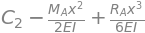

In [8]:
# Integrate again to get deflection

v1 = sp.integrate(v1_prime, x) + C2
v1

In [9]:
C2_soln=sp.solve(v1.subs(x,0), C2)[0]
C2_soln

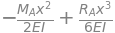

In [10]:
v1 = v1.subs(C2,C2_soln)  # Corrected to properly substitute C2_soln
v1

## For a <= x <= L:

In [11]:
# Moment function for a <= x <= L
M2 = R_A * x  - M_A - P * (x - a)
#M2 = M2.subs({R_B: R_B_soln, M_B: M_B_soln}).together()
#M2 = R_B * (L - x) + M_B
#?sp.polys
#?sp.polys.together

print(M1)
print(M2)

-M_A + R_A*x
-M_A - P*(-a + x) + R_A*x


In [13]:
M2.subs(M_A,-M_B-R_B*L+P*a).subs(R_A, P-R_B).simplify()

In [12]:
# For a <= x <= L
C3, C4 = sp.symbols('C3 C4')  # Update symbols for integration constants
v2_prime = sp.integrate(M2, x) / (E * I) + C3
v2_prime

Continuity of the slope at x=a:
$$ v2'(a) = v1'(a) $$

In [13]:
# C3_soln=sp.solve(v2_prime.subs(x,L), C3)[0]
C3_soln=sp.solve(v2_prime.subs(x,a)-v1_prime.subs(x,a), C3)[0]
C3_soln

In [14]:
# Configure SymPy to display polynomials in descending order of powers
#sp.init_printing(order='rev-lex')

v2_prime=v2_prime.subs(C3,C3_soln)
v2_prime=v2_prime.expand(x).collect(x)

v2_prime

In [15]:
v2 = sp.integrate(v2_prime, x) + C4
v2 = v2.expand(x).collect(x)
v2


Continuity of the deflection at x=a:
$$ v_2(a) = v_1(a) $$

In [18]:
# C4_soln=sp.solve(v2.subs(x,L), C4)[0]

In [16]:
print(simplify(v2.subs(x,a)-v1.subs(x,a)))
C4_soln=sp.solve(v2.subs(x,a)-v1.subs(x,a), C4)[0]
C4_soln

C4 - P*a**3/(6*E*I)


In [17]:
v2=v2.subs(C4,C4_soln)
v2

In [21]:
# Apply boundary conditions:
# v(0) = 0
# v(L) = 0
# v1(a) == v2(a) (continuity)
# v1_prime.subs(x=a) == v2_prime.subs(x=a) (slope continuity)

# # Substitute integration constants
# v1_prime = v1_prime.subs('C1', C1)
# v2_prime = v2_prime.subs('C2', C2)
# v1 = v1.subs('C3', C3)
# v2 = v2.subs('C4', C4)

# Set up equations
eqs = [
	# v1.subs(x, 0),  # v(0) = 0
	eqn_force,
	eqn_moment,
	v2.subs(x, L),  # v(L) = 0
	v2_prime.subs(x, L),  # v'(L) = 0
	# sp.simplify(v1.subs(x, a) - v2.subs(x, a)),  # continuity at x=a
	# sp.simplify(v1_prime.subs(x, a) - v2_prime.subs(x, a)),  # slope continuity at x=a
	# a+b-L
]
eqs

{M_A: (L**2*P*a - 2*L*P*a**2 + P*a**3)/L**2, M_B: (-L*P*a**2 + P*a**3)/L**2, R_A: (L**3*P - 3*L*P*a**2 + 2*P*a**3)/L**3, R_B: (3*L*P*a**2 - 2*P*a**3)/L**3}
{M_A: P*a*(-L + a)**2/L**2, M_B: P*a**2*(-L + a)/L**2, R_A: P*(-L + a)**2*(L + 2*a)/L**3, R_B: -P*a**2*(-3*L + 2*a)/L**3}


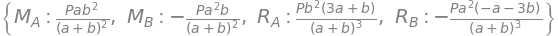

In [22]:
# Solve for constants
#?sp.solve
soln = sp.solve(eqs, (R_A, M_A, R_B, M_B), dict=True)[0]
print(soln)
soln = sp.factor(soln)
print(soln)
soln=soln.subs(L, a + b)
soln

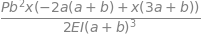

In [23]:
# Substitute integration constants
v1_prime = v1_prime.subs(soln).simplify()

#sp.pprint(v1_prime)
#v1_prime = v1_prime.simplify().factor()
v1_prime

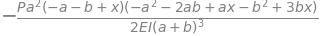

In [24]:
v2_prime = v2_prime.subs(soln).factor()
v2_prime

In [ ]:
v1 = v1.subs(soln)
print(v1.together())
v1

In [ ]:
v2 = v2.subs(soln)
v2

In [ ]:
# Symbolic piecewise polynomial

M_piecewise = sp.Piecewise(
	(M1, x < a),
	(M2, x >= a)
)

# Display the piecewise function
print("Symbolic piecewise moment function:")
M_piecewise

In [ ]:
soln[R_A]

In [ ]:
soln[M_A]

In [ ]:
# Simplify the expression
M_soln = M_piecewise.subs(soln)
print("\nSimplified form:")
M_soln

In [ ]:

# Example: Calculate the moment at specific points
print("\nMoment at x=0:", M_soln.subs(x, 0))

In [ ]:
print("Moment at x=a:")
M_soln.subs(x, a).simplify()

In [ ]:
# First, substitute x=L
moment_at_L = M_soln.subs(x, a+b).simplify()
print("Moment at x=L:")
moment_at_L

## Creating a Piecewise Slope Function

We'll now create a piecewise function combining v1_prime and v2_prime, and visualize it with sample values.


In [ ]:
# Create a piecewise function for the slope
v_prime_piecewise = sp.Piecewise(
	(v1_prime, x < a),
	(v2_prime, x >= a)
)

# Display the piecewise function
print("Symbolic piecewise slope function:")
v_prime_piecewise


In [62]:
# Define sample values for the constants

params={
	L: 10.0,  # Length of beam (m)
	a: 4.0,   # Position of point load (m)
	b: 6.0,
	P: 1e3,   # Magnitude of point load (N)
	E: 2e11,  # Young's modulus (Pa) - typical for steel
	I: 1e-4   # Moment of inertia (m^4)
}

# Substitute the values
v_prime_numeric = v_prime_piecewise.subs(params)
v_prime_numeric

⎧     9.0e-7⋅x⋅(18.0⋅x - 80.0)        for x < 4.0
⎨                                                
⎩-4.0e-7⋅(x - 10.0)⋅(22.0⋅x - 100.0)   otherwise 

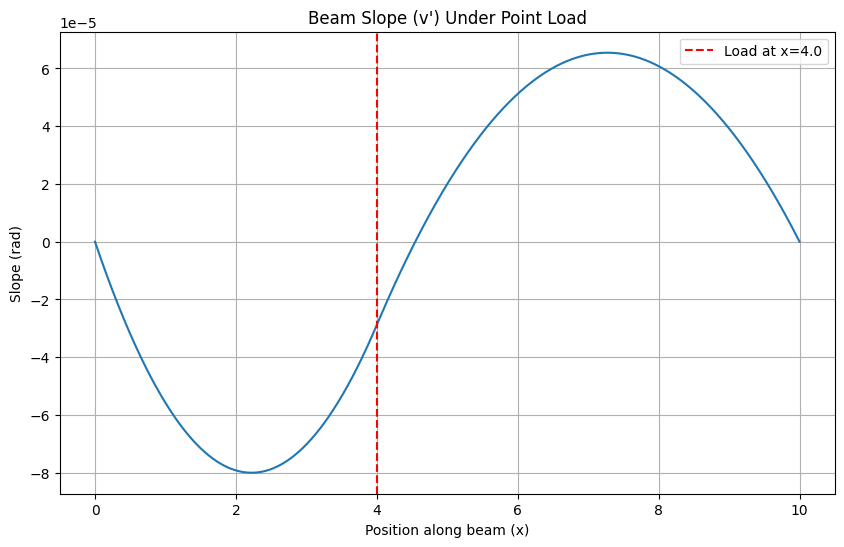

In [66]:
# Create a numerical function for plotting
import numpy as np
import matplotlib.pyplot as plt
from sympy import lambdify

v_prime_func = lambdify(x, v_prime_numeric, "numpy")

# Create x values for plotting
x_vals = np.linspace(0.0, params[L], 10**3, dtype=float)
y_vals = v_prime_func(x_vals)

# Plot the slope
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals)
plt.axvline(x=params[a], color='r', linestyle='--', label=f'Load at x={params[a]}')
plt.title('Beam Slope (v\') Under Point Load')
plt.xlabel('Position along beam (x)')
plt.ylabel('Slope (rad)')
plt.grid(True)
plt.legend()
plt.show()


## Creating a Piecewise Deflection Function

Now we'll visualize the deflection (v) along the beam.


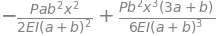

In [67]:
v1

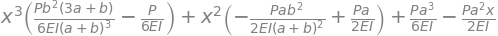

In [68]:
v2

In [ ]:
# Create a piecewise function for the deflection
v_piecewise = sp.Piecewise(
	(v1, x < a),
	(v2, x >= a)
)

# Display the piecewise function
print("Symbolic piecewise deflection function:")
v_piecewise

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import lambdify

# Substitute values
v_numeric = v_piecewise.subs(params)

# Create a numerical function for plotting
v_func = lambdify(x, v_numeric, "numpy")

# Plot the deflection
plt.figure(figsize=(10, 6))
plt.plot(x_vals, v_func(x_vals))
plt.axvline(x=params[a], color='r', linestyle='--', label=f'Load at x={params[a]}')
plt.title('Beam Deflection (v) Under Point Load')
plt.xlabel('Position along beam (x)')
plt.ylabel('Deflection (m)')
plt.grid(True)
plt.legend()
plt.show()

## Demonstration of Fixed-End Shears

For a beam with fixed ends and a point load P at distance a from the left end:

$$ V_{FA} = \frac{Pb^2}{L^3}(3a+b) $$
$$ V_{FB} = \frac{Pa^2}{L^3}(a+3b) $$

Let's verify these formulas through our symbolic analysis.


In [ ]:
# Fixed-End Shears formulas
V_FA_formula = P*b**2*(3*a+b)/L**3
V_FB_formula = P*a**2*(a+3*b)/L**3

# Display the formulas
print("Fixed-End Shear at A:")
sp.pprint(V_FA_formula)
print("\nFixed-End Shear at B:")
sp.pprint(V_FB_formula)

# Create piecewise function for the moment with fixed-end conditions
M_fixed_piecewise = sp.Piecewise(
	(R_A * x - M_A, x < a),
	(R_A * x - M_A - P * (x - a), x >= a)
)

# Create piecewise function for shear (derivative of moment)
V_fixed = sp.diff(M_fixed_piecewise, x)

print("\nShear Force Function (derivative of moment):")
V_fixed

In [51]:
fixed_vals=soln.subs(params)
fixed_vals

In [55]:
# Visualize the shear force and moment diagrams for fixed-end conditions
# First, substitute the values of R_A, M_A, etc. for fixed-end conditions

# For fixed ends: R_A = V_FA, R_B = V_FB, M_A and M_B are the fixed-end moments
# fixed_vals = {
# 	R_A: V_FA_formula.subs({L: params[L], a: params[a], b: params[L]-params[a], P: params[P]}),
# 	M_A: -params[P]*params[L]-params[a]**2*params[a]/params[L]**2,  # Fixed-end moment at A
# 	P: params[P],
# 	a: params[a]
# }

M_fixed_numeric = M_fixed_piecewise.subs(fixed_vals)
V_fixed_numeric = V_fixed.subs(fixed_vals)

# Create numerical functions for plotting
M_fixed_func = lambdify(x, M_fixed_numeric, "numpy")
V_fixed_func = lambdify(x, V_fixed_numeric, "numpy")

TypeError: cannot determine truth value of Relational: a > 0.01001001001001

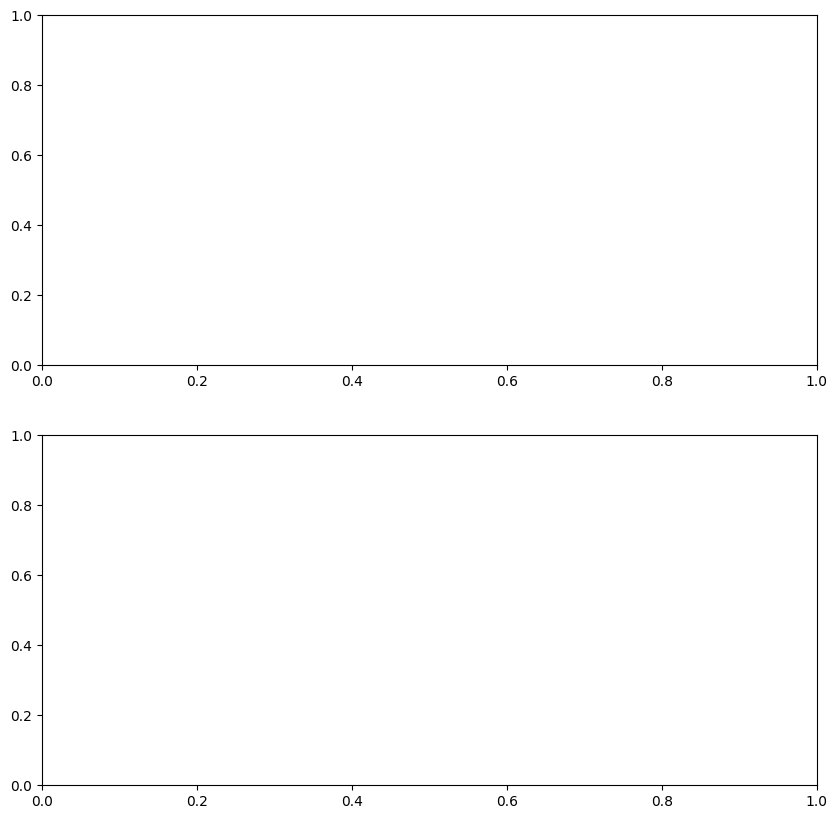

In [56]:
# Plot moment and shear
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
params[a]=fixed_vals[a]
ax1.plot(x_vals, M_fixed_func(x_vals))
ax1.axvline(x=params[a], color='r', linestyle='--', label=f'Load at x={params[a]}')
ax1.set_title('Fixed-End Bending Moment Diagram')
ax1.set_ylabel('Moment (N·m)')
ax1.grid(True)
ax1.legend()

ax2.plot(x_vals, V_fixed_func(x_vals))
ax2.axvline(x=params[a], color='r', linestyle='--', label=f'Load at x={params[a]}')
ax2.set_title('Fixed-End Shear Force Diagram')
ax2.set_xlabel('Position along beam (x)')
ax2.set_ylabel('Shear Force (N)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Verify that the fixed-end shear at x=0 matches our formula
V_at_A = V_fixed_numeric.subs(x, 0)
print("Shear at A from our analysis:", V_at_A)
print("Shear at A from formula:", V_FA_formula.subs({L: params[L], a: params[a], b: params[L]-params[a], P: params[P]}))
print("Match:", sp.simplify(V_at_A - V_FA_formula.subs({L: params[L], a: params[a], b: params[L]-params[a], P: params[P]})) == 0)

# Verify that the fixed-end shear at x=L matches our formula
V_at_B = -V_fixed_numeric.subs(x, params[L])  # Negative because of sign convention
print("\nShear at B from our analysis:", V_at_B)
print("Shear at B from formula:", V_FB_formula.subs({L: params[L], a: params[a], b: params[L]-params[a], P: params[P]}))
print("Match:", sp.simplify(V_at_B - V_FB_formula.subs({L: params[L], a: params[a], b: params[L]-params[a], P: params[P]})) == 0)

